## What is the most optimal skill to learn for Data Analysts?

### Methodology
1. Group skills to determine median salary and likelihood of being in posting  
2. Visualize median salary vs percent skill demand  
3. (Optional) Determine if certain technologies are more prevalent


In [15]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import seaborn as sns
from datetime import datetime as dt

# Loading Data & Cleaning Up
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\data_jobs.csv')
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [16]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

df_da_us_exploded = df_da_us.explode('job_skills')

df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)


,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [17]:
df_da_us_skills = df_da_us_exploded.groupby('job_skills')['salary_year_avg'] \
    .agg(['count', 'median']) \
    .sort_values(by='count', ascending=False)

df_da_us_skills = df_da_us_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

da_job_count = len(df_da_us)
skill_percent = 5

df_da_us_skills['skill_percent'] = df_da_us_skills['skill_count'] / da_job_count * 100
df_da_skills_high_demand = df_da_us_skills[df_da_us_skills['skill_percent'] > skill_percent]

df_da_skills_high_demand


,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


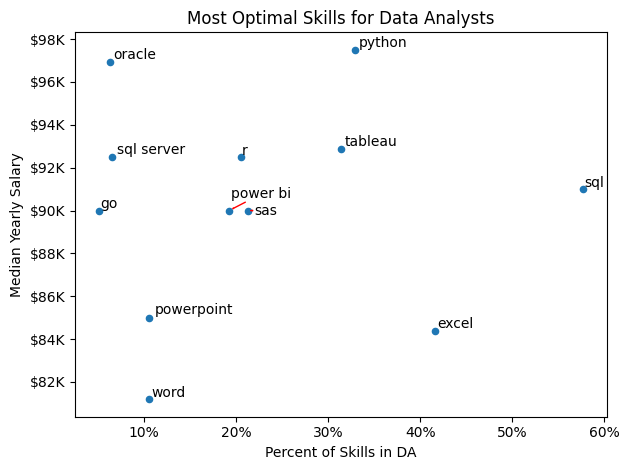

In [18]:
from adjustText import adjust_text

df_da_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.xlabel('Percent of Skills in DA')
plt.ylabel('Median Yearly Salary')
plt.title(f'Most Optimal Skills for Data Analysts')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.show()


In [20]:
df['job_type_skills'].sample(10)

696176                             {'programming': ['sql']}
693545    {'analyst_tools': ['excel', 'spreadsheet'], 'o...
212610    {'cloud': ['aws', 'redshift'], 'databases': ['...
297082              {'programming': ['sql', 'r', 'python']}
359835                           {'analyst_tools': ['sap']}
641252    {'cloud': ['snowflake', 'databricks'], 'progra...
271923    {'analyst_tools': ['tableau'], 'programming': ...
589466    {'async': ['jira', 'planner'], 'cloud': ['orac...
32317     {'analyst_tools': ['sheets', 'ms access'], 'pr...
162786                         {'programming': ['crystal']}
Name: job_type_skills, dtype: str

In [ ]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  
    for key, value in row_dict.items():
        if key in technology_dict: 
            technology_dict[key] += value
        else:  
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))
    
technology_dict


{'analyst_tools': ['powerbi',
  'power bi',
  'excel',
  'looker',
  'msaccess',
  'visio',
  'spss',
  'qlik',
  'powerpoint',
  'sheets',
  'alteryx',
  'datarobot',
  'spreadsheet',
  'esquisse',
  'outlook',
  'microstrategy',
  'sas',
  'ms access',
  'splunk',
  'sharepoint',
  'tableau',
  'nuix',
  'ssis',
  'cognos',
  'word',
  'ssrs',
  'dax',
  'sap'],
 'programming': ['golang',
  'clojure',
  'kotlin',
  'ocaml',
  'assembly',
  'sass',
  'mongodb',
  'fortran',
  'dart',
  'lua',
  'apl',
  'haskell',
  'julia',
  'scala',
  'java',
  'vba',
  'typescript',
  'swift',
  'pascal',
  'lisp',
  't-sql',
  'mongo',
  'elixir',
  'sql',
  'rust',
  'f#',
  'ruby',
  'perl',
  'go',
  'matlab',
  'nosql',
  'delphi',
  'erlang',
  'bash',
  'powershell',
  'sas',
  'r',
  'vb.net',
  'crystal',
  'shell',
  'objective-c',
  'visualbasic',
  'javascript',
  'c',
  'groovy',
  'css',
  'html',
  'c#',
  'visual basic',
  'python',
  'no-sql',
  'php',
  'cobol',
  'c++',
  'solid

In [25]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns = ['technology', 'skills'])

In [26]:
df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,powerbi
0,analyst_tools,power bi
0,analyst_tools,excel
0,analyst_tools,looker
0,analyst_tools,msaccess
...,...,...
9,sync,wire
9,sync,symphony
9,sync,rocketchat
9,sync,zoom


In [28]:
df_plot = df_da_skills_high_demand.merge(df_technology, left_on = 'job_skills', right_on = 'skills')

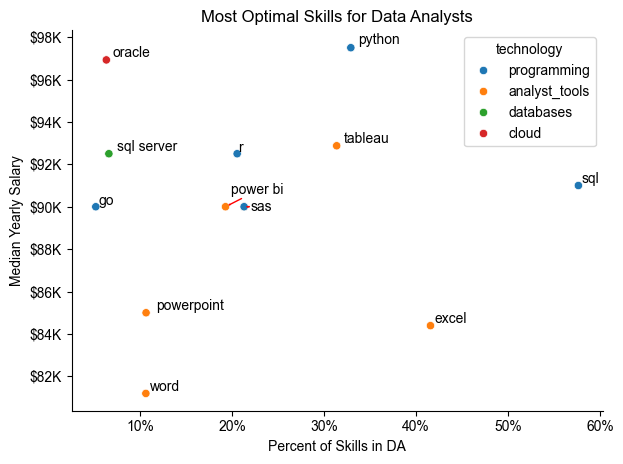

In [32]:

sns.scatterplot(
    data = df_plot,
    x = 'skill_percent',
    y = 'median_salary',
    hue = 'technology'
)

texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
sns.despine()
sns.set_theme(style = 'ticks')
plt.xlabel('Percent of Skills in DA')
plt.ylabel('Median Yearly Salary')
plt.title(f'Most Optimal Skills for Data Analysts')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.show()